In [1]:
'''
Here we monitored the fitness decay relative to its initial state (the origin) as the optimum moved. Here 3 movement strategies
are tested. 

1. move along all dimension deterministically
2. move along the diagonal deterministically
3. move along one dimnesion deterministically

'''

'\nHere we monitored the fitness decay relative to its initial state (the origin) as the optimum moved. Here 3 movement strategies\nare tested. \n\n1. move along all dimension deterministically\n2. move along the diagonal deterministically\n3. move along one dimnesion deterministically\n\n'

In [2]:
from __future__ import division
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [3]:
generation_list = []

for i in range(2002):
    generation_list.append(i)
    
print(len(generation_list))

2002


In [4]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
       
        fit_mean.extend(list(pd.Series(f.OptFitness_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.OptFitness_Std,dtype=float)))
    
    
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        
    return total_fit_mean, total_fit_std

### 1. Move along all dimensions deterministically

In [5]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190223_Test of FGM_Movement of Optimum\Data\1.1. Along All Dimensions")

In [6]:
all_dim = ['NoPley_Move_STD_001.csv', 'NoPley_Move_STD_002.csv']

In [7]:
ad = get_data1(all_dim)

ad_fit_mean =ad[0]
ad_fit_std = ad[1]

In [8]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 30})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(8)
    ax.spines['bottom'].set_linewidth(8)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')

(0, 1)

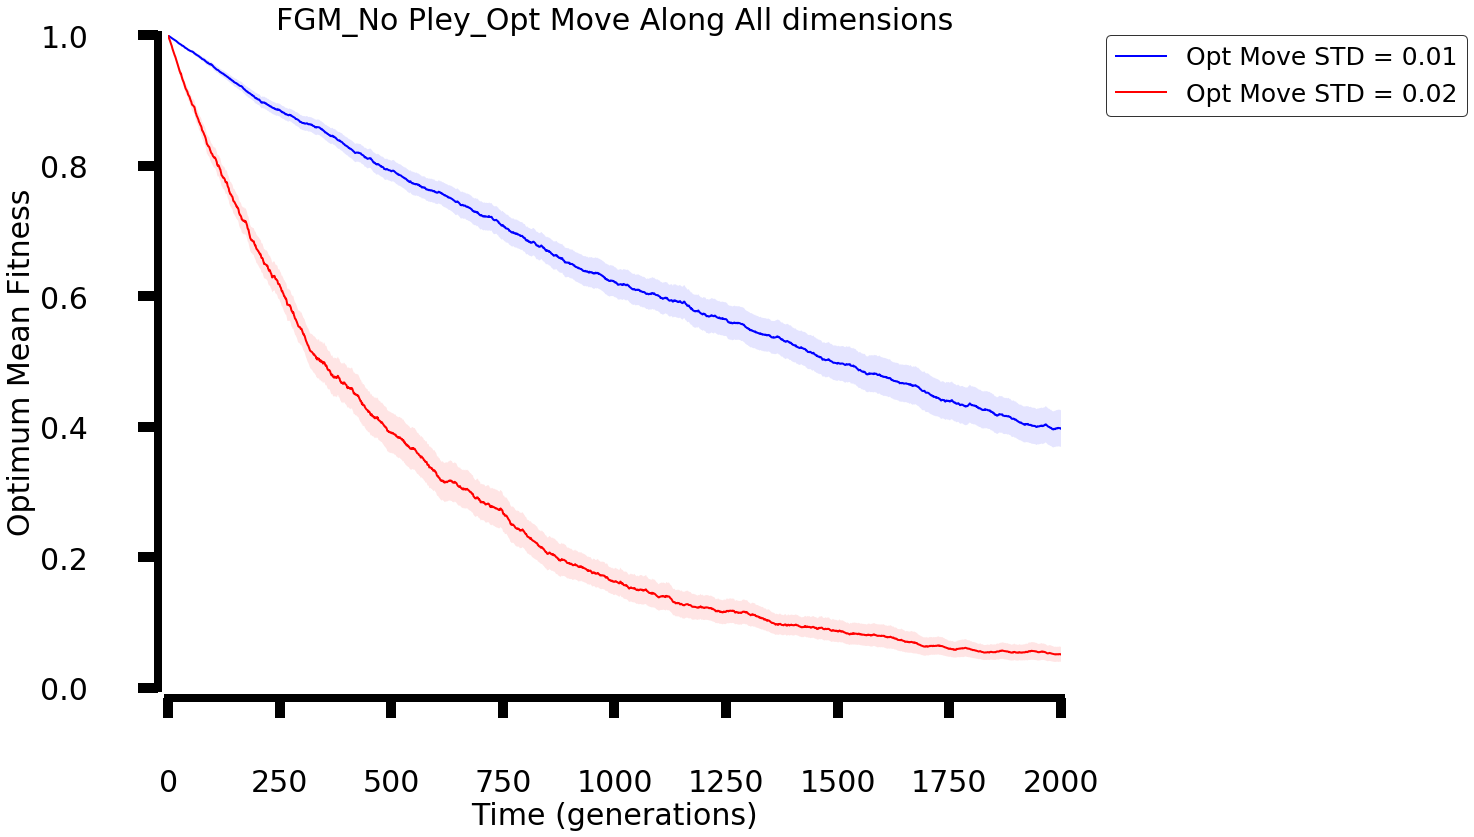

In [10]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,2000)

t = generation_list

a1 = ad_fit_mean[0]
error_a1 = list(1.96* np.array(ad_fit_std[0])/((100)**0.5))

a2 = ad_fit_mean[1]
error_a2 = list(1.96* np.array(ad_fit_std[1])/((100)**0.5))

ax.set_title('FGM_No Pley_Opt Move Along All dimensions', fontsize =30)
ax.set_xlabel('Time (generations)', fontsize =30)
ax.set_ylabel('Optimum Mean Fitness', fontsize =30)


ax.plot(t,a1,'b', label = 'Opt Move STD = 0.01',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.1, facecolor='b')

ax.plot(t,a2,'r', label = 'Opt Move STD = 0.02',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.1, facecolor='r')


# plt.axhline(y=0.5, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')

# extraticks=[0.45]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0, 1)



# plt.show()
# plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

In [12]:
print 'S1 Opt_Mean', ad_fit_mean[0][-1]
print 'S1 Opt_95% CI_Lower', ad_fit_mean[0][-1]-1.98*ad_fit_std[0][-1]/10
print 'S1 Opt_95% CI_Upper', ad_fit_mean[0][-1]+1.98*ad_fit_std[0][-1]/10

S1 Opt_Mean 0.396796288924
S1 Opt_95% CI_Lower 0.368551389262
S1 Opt_95% CI_Upper 0.425041188586


### 2. Move along one dimension deterministically

In [13]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190223_Test of FGM_Movement of Optimum\Data\1.2. Along One Dimension")

In [14]:
one_dim = ['NoPley_OneDim_Move_STD001.csv', 'NoPley_OneDim_Move_STD005.csv', 'NoPley_OneDim_Move_STD01.csv']

In [15]:
od = get_data1(one_dim)

od_fit_mean =od[0]
od_fit_std = od[1]

(0, 1)

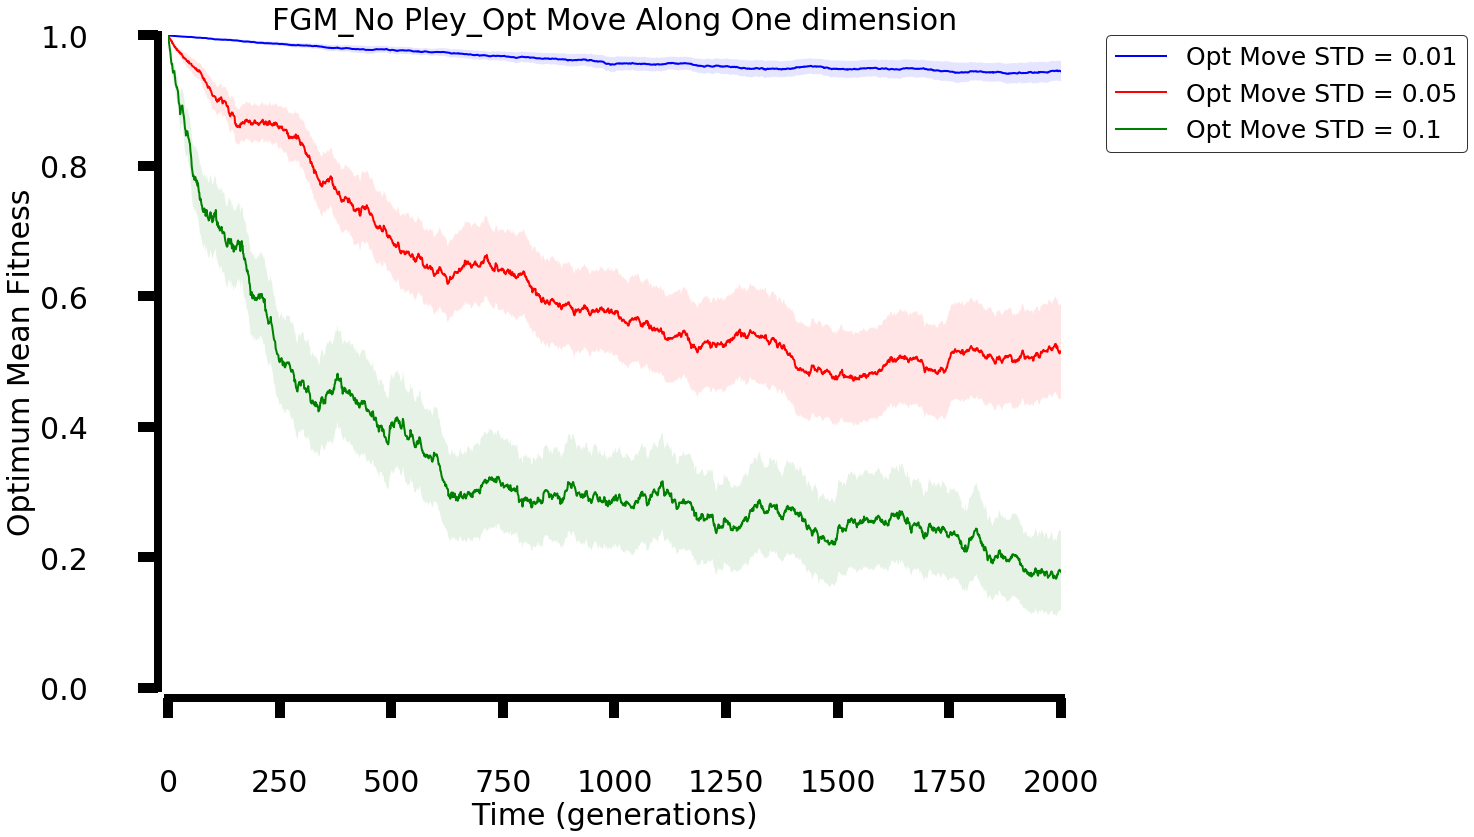

In [16]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,2000)

t = generation_list

a1 = od_fit_mean[0]
error_a1 = list(1.96* np.array(od_fit_std[0])/((100)**0.5))

a2 = od_fit_mean[1]
error_a2 = list(1.96* np.array(od_fit_std[1])/((100)**0.5))

a3 = od_fit_mean[2]
error_a3 = list(1.96* np.array(od_fit_std[2])/((100)**0.5))

ax.set_title('FGM_No Pley_Opt Move Along One dimension', fontsize =30)
ax.set_xlabel('Time (generations)', fontsize =30)
ax.set_ylabel('Optimum Mean Fitness', fontsize =30)


ax.plot(t,a1,'b', label = 'Opt Move STD = 0.01',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.1, facecolor='b')

ax.plot(t,a2,'r', label = 'Opt Move STD = 0.05',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.1, facecolor='r')

ax.plot(t,a3,'g', label = 'Opt Move STD = 0.1',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.1, facecolor='g')


# plt.axhline(y=0.5, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')

# extraticks=[0.45]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0, 1)



# plt.show()
# plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

In [17]:
print 'S1 Opt_Mean', od_fit_mean[1][-1]
print 'S1 Opt_95% CI_Lower', od_fit_mean[1][-1]-1.98*od_fit_std[1][-1]/10
print 'S1 Opt_95% CI_Upper', od_fit_mean[1][-1]+1.98*od_fit_std[1][-1]/10

S1 Opt_Mean 0.514509468244
S1 Opt_95% CI_Lower 0.441537378502
S1 Opt_95% CI_Upper 0.587481557986


### 3. Move along the diagonal of the optimum deterministically

In [18]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190223_Test of FGM_Movement of Optimum\Data\1.3. StraightLine Move")

In [19]:
dg_line = ['StraightLine_Move_STD_Rate0001.csv', 'StraightLine_Move_STD_Rate0003.csv', 'StraightLine_Move_STD_Rate0005.csv']

In [20]:
dl = get_data1(dg_line)

dl_fit_mean =dl[0]
dl_fit_std = dl[1]

(0, 1)

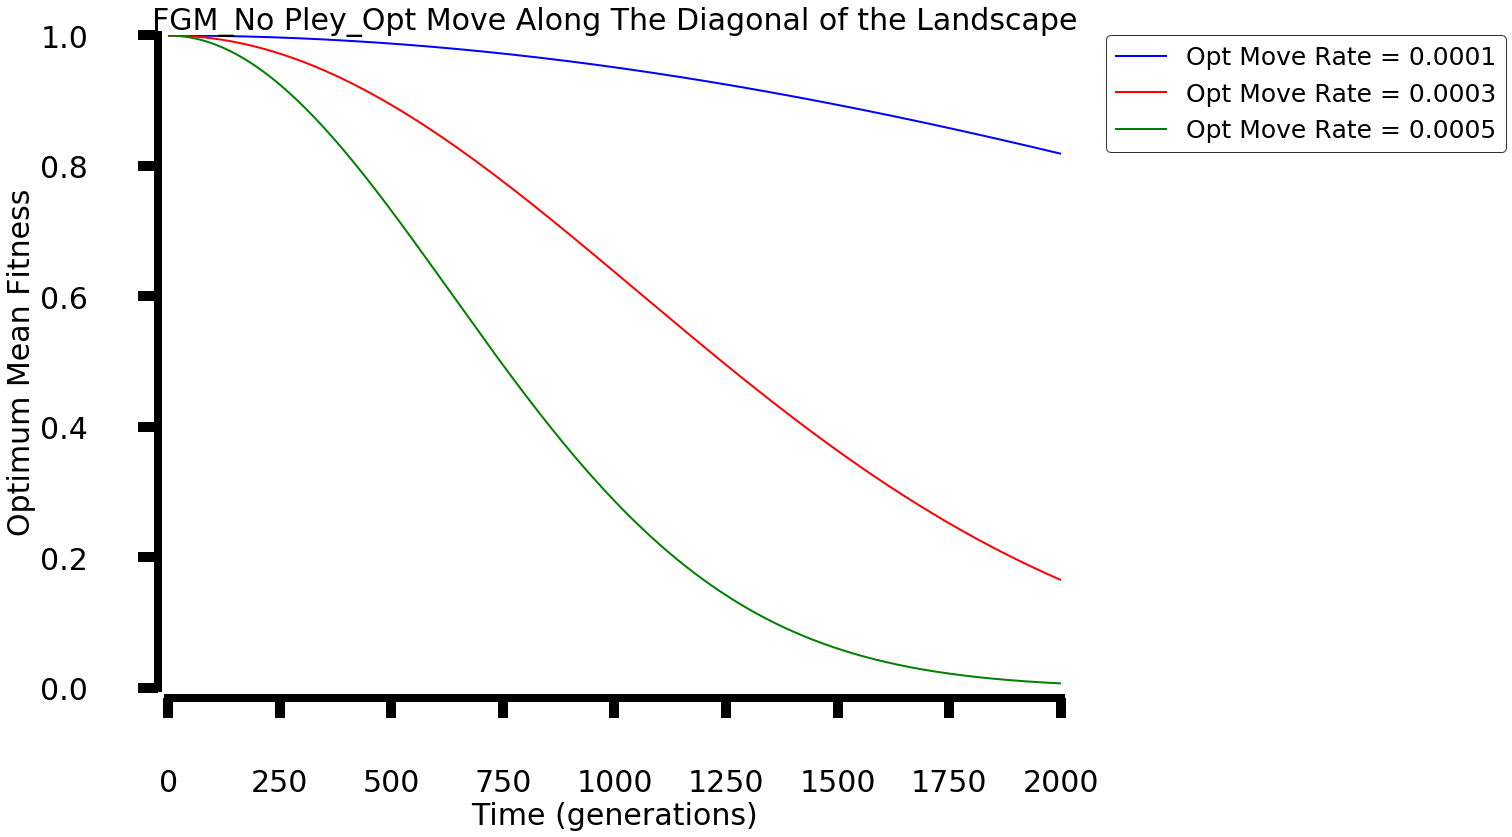

In [21]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,2000)

t = generation_list

a1 = dl_fit_mean[0]
error_a1 = list(1.96* np.array(dl_fit_std[0])/((100)**0.5))

a2 = dl_fit_mean[1]
error_a2 = list(1.96* np.array(dl_fit_std[1])/((100)**0.5))

a3 = dl_fit_mean[2]
error_a3 = list(1.96* np.array(dl_fit_std[2])/((100)**0.5))

ax.set_title('FGM_No Pley_Opt Move Along The Diagonal of the Landscape', fontsize =30)
ax.set_xlabel('Time (generations)', fontsize =30)
ax.set_ylabel('Optimum Mean Fitness', fontsize =30)


ax.plot(t,a1,'b', label = 'Opt Move Rate = 0.0001',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.1, facecolor='b')

ax.plot(t,a2,'r', label = 'Opt Move Rate = 0.0003',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.1, facecolor='r')

ax.plot(t,a3,'g', label = 'Opt Move Rate = 0.0005',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.1, facecolor='g')


# plt.axhline(y=0.5, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')

# extraticks=[0.45]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0, 1)



# plt.show()
# plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

In [22]:
print 'S3 Opt_Mean', dl_fit_mean[1][-1]
print 'S3 Opt_95% CI_Lower', dl_fit_mean[1][-1]-1.98*dl_fit_std[1][-1]/10
print 'S3 Opt_95% CI_Upper', dl_fit_mean[1][-1]+1.98*dl_fit_std[1][-1]/10

S3 Opt_Mean 0.165001543596
S3 Opt_95% CI_Lower 0.165001543596
S3 Opt_95% CI_Upper 0.165001543596
